# Melbourne Housing Price Prediction  
### End-to-End Machine Learning Project

**Author:** Richard Hanly   
**Project Type:** Applied Machine Learning / Data Science  

---

## Project Summary

This project develops a machine learning pipeline to analyze and predict housing prices using the Melbourne Housing Market dataset. The analysis includes data cleaning, feature engineering, exploratory data analysis, and predictive modeling.

Two models are implemented and evaluated:

- **Linear Regression** – baseline predictive model  
- **Random Forest Regressor** – tuned model capturing nonlinear relationships  

Model performance is evaluated using **MAE, RMSE, and R² metrics**, and results are interpreted through feature importance analysis and prediction visualization.

---

<details>
<summary><strong>Table of Contents</strong></summary>

- [Project Overview](#project-overview)
- [Dataset](#dataset)
- [Project Workflow](#project-workflow)
- [Modeling Objective](#modeling-objective)

- [Library Imports](#library-imports)
- [Data Loading](#data-loading)
- [Initial Data Inspection](#initial-data-inspection)
- [Data Cleaning](#data-cleaning)

- [Feature Transformation and Encoding](#feature-transformation-and-encoding)

- [Data Exploration and Visualization](#data-exploration-and-visualization)
  - [Descriptive Statistics](#descriptive-statistics)
  - [Data Visualizations](#data-visualizations)
  - [Exploratory Insights](#exploratory-insights)

- [Model Preparation](#model-preparation)
  - [Train/Test Split](#traintest-split)

- [Baseline Model: Linear Regression](#baseline-model-linear-regression)

- [Random Forest Hyperparameter Tuning](#random-forest-hyperparameter-tuning)
- [Random Forest Regressor](#random-forest-regressor)

- [Model Evaluation](#model-evaluation)
- [Model Comparison](#model-comparison)

- [Feature Importance Analysis](#feature-importance-analysis)
- [Prediction Performance Visualization](#prediction-performance-visualization)

- [Conclusion](#conclusion)
- [Future Improvements](#future-improvements)

</details>

## Project Overview

This project develops a machine learning model to predict housing prices using the Melbourne Housing Market dataset. The goal is to explore key factors that influence property values and build predictive models capable of estimating housing prices based on structural and location-based features.

The analysis follows a complete data science workflow including data cleaning, exploratory analysis, feature engineering, and predictive modeling.

### Project Highlights

- End-to-end machine learning workflow
- Data cleaning and preprocessing
- Outlier detection and treatment
- Feature engineering and encoding
- Linear regression baseline model
- Random forest regression model
- Feature importance analysis
- Prediction performance visualization

## Dataset

The dataset contains housing transaction data from Melbourne, Australia, including property attributes, location information, and sale prices.

Key features include:

- **Rooms** – number of rooms in the property
- **Distance** – distance from Melbourne's central business district
- **Bedroom2 / Bathroom / Car** – structural characteristics
- **Landsize / BuildingArea** – physical size of the property
- **YearBuilt** – year the property was constructed

The target variable for prediction is Price, representing the sale price of each property.

## Project Workflow

The analysis follows these steps:

1. Data Cleaning and Preparation  
2. Handling Missing Values  
3. Outlier Detection and Treatment  
4. Feature Transformation and Encoding  
5. Train-Test Data Splitting  
6. Baseline Model: Linear Regression  
7. Random Forest Regression Model  
8. Model Evaluation and Comparison  
9. Feature Importance Analysis  
10. Prediction Performance Visualization

## Modeling Objective

The primary objective of this project is to develop a predictive model capable of estimating housing prices based on available property attributes. Two models are trained and evaluated:

- **Linear Regression**, used as a baseline model
- **Random Forest Regressor**, used to capture nonlinear relationships in the data

Model performance is evaluated using standard regression metrics including Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² score.

## Library Imports

The following libraries are used for data manipulation, visualization, and preprocessing.



In [ ]:
import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import kagglehub

plt.style.use("seaborn-v0_8")
sns.set_palette("tab10")
pd.set_option("display.max_columns", None)

## Data Loading

The dataset is loaded into a pandas DataFrame for analysis and preprocessing.

In [ ]:
import kagglehub

# Download latest version of the dataset
path = kagglehub.dataset_download("dansbecker/melbourne-housing-snapshot")

print("Path to dataset files:", path)
import pandas as pd
import os

# Find the CSV file
for file in os.listdir(path):
    print(file)

csv_path = os.path.join(path, "melb_data.csv")
df = pd.read_csv(csv_path)

Using Colab cache for faster access to the 'melbourne-housing-snapshot' dataset.
Path to dataset files: /kaggle/input/melbourne-housing-snapshot
melb_data.csv


## Initial Data Inspection

Before preprocessing, it is useful to inspect the structure of the dataset, check variable types, and identify missing values.

In [ ]:
df.info()

df.describe(include="all")

df.shape


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         13580 non-null  object 
 1   Address        13580 non-null  object 
 2   Rooms          13580 non-null  int64  
 3   Type           13580 non-null  object 
 4   Price          13580 non-null  float64
 5   Method         13580 non-null  object 
 6   SellerG        13580 non-null  object 
 7   Date           13580 non-null  object 
 8   Distance       13580 non-null  float64
 9   Postcode       13580 non-null  float64
 10  Bedroom2       13580 non-null  float64
 11  Bathroom       13580 non-null  float64
 12  Car            13518 non-null  float64
 13  Landsize       13580 non-null  float64
 14  BuildingArea   7130 non-null   float64
 15  YearBuilt      8205 non-null   float64
 16  CouncilArea    12211 non-null  object 
 17  Lattitude      13580 non-null  float64
 18  Longti

(13580, 21)

## Data Cleaning

Missing values and inconsistent data types were addressed to ensure the dataset is suitable for analysis. Numerical features were handled using median imputation, while categorical features were filled using the most frequent category.

**Identify Missing Values**

In [ ]:
df.isnull().sum()

,0
Suburb,0
Address,0
Rooms,0
Type,0
Price,0
Method,0
SellerG,0
Date,0
Distance,0
Postcode,0


In [ ]:
# Identify numerical and categorical columns
num_features = df.select_dtypes(include=['int64', 'float64']).columns
cat_features = df.select_dtypes(include=['object']).columns

num_features, cat_features

# Impute numerical columns with the median
for col in num_features:
    df[col] = df[col].fillna(df[col].median())

# Impute categorical columns with the mode
for col in cat_features:
    df[col] = df[col].fillna(df[col].mode()[0])

df.isnull().sum()


,0
Suburb,0
Address,0
Rooms,0
Type,0
Price,0
Method,0
SellerG,0
Date,0
Distance,0
Postcode,0


## Feature Transformation and Encoding

Categorical variables must be converted to numerical form before applying machine learning algorithms.  
High-cardinality categorical features such as Address, Suburb, SellerG, CouncilArea, and Regionname were removed prior to encoding because they contain a large number of unique values that would create thousands of sparse dummy variables.

The remaining categorical features were then transformed using one-hot encoding, which represents each category as a binary indicator variable while avoiding artificial ordinal relationships between categories.

In [ ]:
# Remove high-cardinality categorical columns that would create thousands of dummy variables
columns_to_drop = [
    "Address",
    "Suburb",
    "SellerG",
    "CouncilArea",
    "Regionname"
]

# Drop columns safely if they exist
df = df.drop(columns=[col for col in columns_to_drop if col in df.columns])

# Identify remaining categorical columns
cat_features = df.select_dtypes(include="object").columns

# Apply one-hot encoding to categorical variables
df_encoded = pd.get_dummies(df, columns=cat_features)

# Preview encoded dataset (first 10 columns for readability)
df_encoded.iloc[:, :10].head()


,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt
0,2,1480000.0,2.5,3067.0,2.0,1.0,1.0,202.0,126.0,1970.0
1,2,1035000.0,2.5,3067.0,2.0,1.0,0.0,156.0,79.0,1900.0
2,3,1465000.0,2.5,3067.0,3.0,2.0,0.0,134.0,150.0,1900.0
3,3,850000.0,2.5,3067.0,3.0,2.0,1.0,94.0,126.0,1970.0
4,4,1600000.0,2.5,3067.0,3.0,1.0,2.0,120.0,142.0,2014.0


**Visualize Outliers**

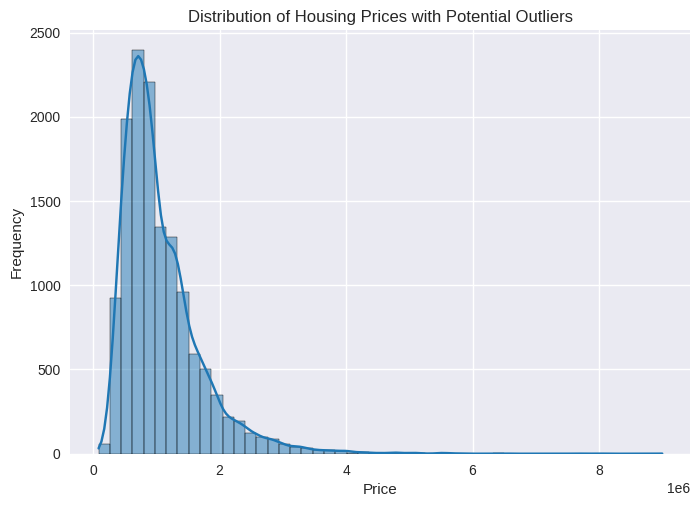

In [ ]:
sns.histplot(df['Price'], bins=50, kde=True)
plt.title('Distribution of Housing Prices with Potential Outliers')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()


**Boxplot for Clear Outlier Identification**

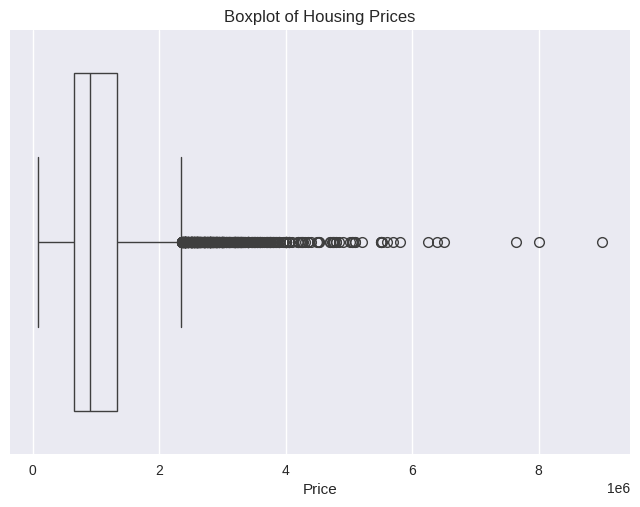

In [ ]:
sns.boxplot(x=df['Price'], showcaps=True, boxprops={'facecolor': 'None'})
plt.title('Boxplot of Housing Prices')
plt.xlabel('Price')
plt.show()


**Outlier Treatment**

In [ ]:
df_original = df.copy()

upper_limit = df["Price"].quantile(0.95)
df["Price"] = np.where(df["Price"] > upper_limit, upper_limit, df["Price"])

**Re-visualize After Treatment**

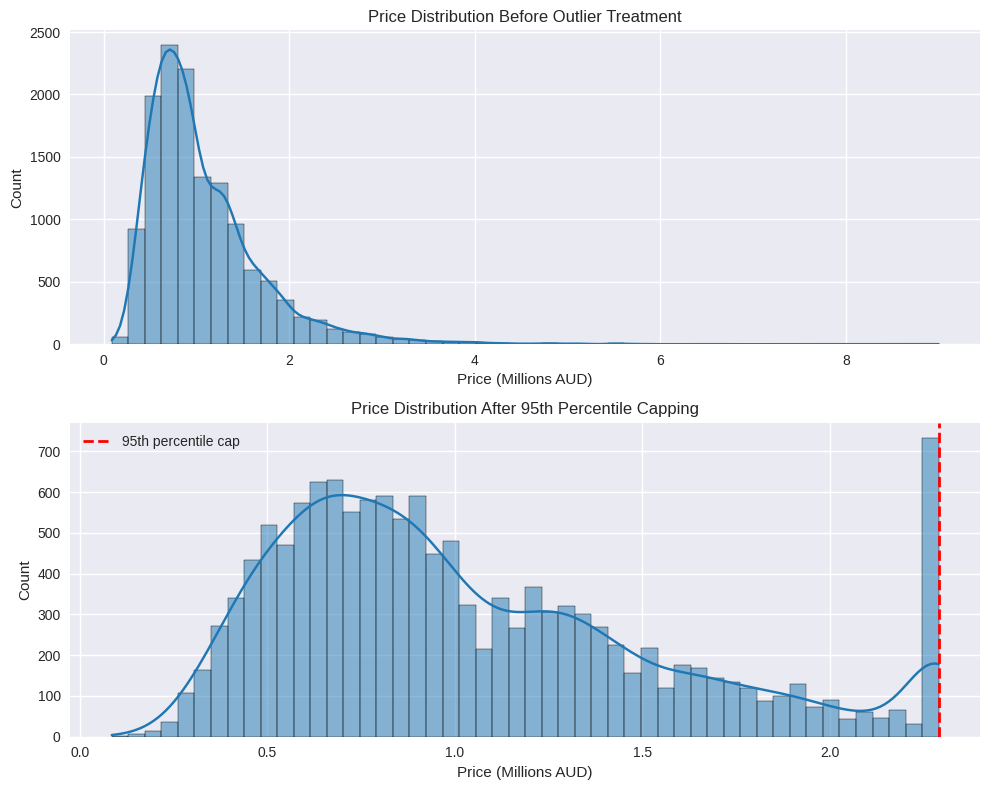

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

# Convert price to millions for readability
price_before = df_original["Price"] / 1_000_000
price_after = df["Price"] / 1_000_000
price_cap_95 = upper_limit / 1_000_000

# Use consistent bins for both plots
bins = 50

sns.histplot(price_before, bins=bins, kde=True, ax=axes[0])
axes[0].set_title("Price Distribution Before Outlier Treatment")
axes[0].set_xlabel("Price (Millions AUD)")
axes[0].set_ylabel("Count")

sns.histplot(price_after, bins=bins, kde=True, ax=axes[1])
axes[1].set_title("Price Distribution After 95th Percentile Capping")
axes[1].set_xlabel("Price (Millions AUD)")
axes[1].set_ylabel("Count")

# Show where the cap occurred
axes[1].axvline(price_cap_95, color="red", linestyle="--", linewidth=2, label="95th percentile cap")
axes[1].legend()

plt.tight_layout()
plt.show()


## Data Exploration and Visualization
This section explores the structure of the dataset using summary statistics and visualizations. The goal is to identify key patterns, variability in housing characteristics, and potential relationships that may influence property prices.


**Descriptive Statistics**

In [ ]:
df.describe()


,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
count,13580.000000,1.358000e+04,13580.000000,13580.000000,13580.000000,13580.000000,13580.000000,13580.000000,13580.000000,13580.000000,13580.000000,13580.000000,13580.000000
mean,2.937997,1.041387e+06,10.137776,3105.301915,2.914728,1.534242,1.611856,558.416127,139.633972,1966.788218,-37.809203,144.995216,7454.417378
std,0.955748,5.201267e+05,5.868725,90.676964,0.965921,0.691712,0.960793,3990.669241,392.217403,29.088642,0.079260,0.103916,4378.581772
min,1.000000,8.500000e+04,0.000000,3000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1196.000000,-38.182550,144.431810,249.000000
25%,2.000000,6.500000e+05,6.100000,3044.000000,2.000000,1.000000,1.000000,177.000000,122.000000,1960.000000,-37.856822,144.929600,4380.000000
50%,3.000000,9.030000e+05,9.200000,3084.000000,3.000000,1.000000,2.000000,440.000000,126.000000,1970.000000,-37.802355,145.000100,6555.000000
75%,3.000000,1.330000e+06,13.000000,3148.000000,3.000000,2.000000,2.000000,651.000000,129.940000,1975.000000,-37.756400,145.058305,10331.000000
max,10.000000,2.290050e+06,48.100000,3977.000000,20.000000,8.000000,10.000000,433014.000000,44515.000000,2018.000000,-37.408530,145.526350,21650.000000


### Insight

The descriptive statistics provide an overview of the numerical features in the Melbourne housing dataset. The average property price is approximately \$1.04 million, with a wide range from around \$85,000 to over \$2.2 million, indicating substantial variation in housing values.

Structural features such as number of rooms, bedrooms, bathrooms, and building area show moderate variation across properties, suggesting diverse property sizes within the dataset. The median property contains three rooms, which appears to be a common configuration.

The distance from the city center ranges from 0 km to nearly 50 km, highlighting the geographic spread of the housing market. This variable is likely to play an important role in explaining price differences, as proximity to central urban areas often influences property values.

Overall, the dataset exhibits significant variability in both property characteristics and pricing, making it suitable for predictive modeling and feature analysis.

**Data Visualization**

### Relationship Between Number of Rooms and Price

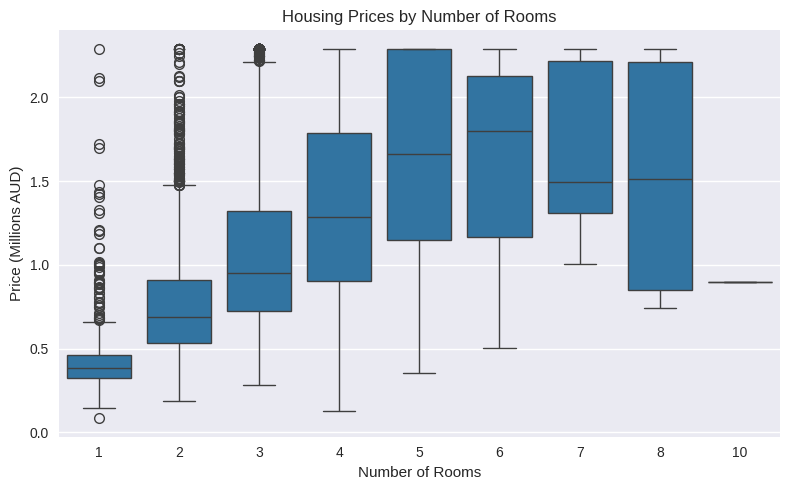

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["Rooms"],
    y=df["Price"] / 1_000_000
)

plt.title("Housing Prices by Number of Rooms")
plt.xlabel("Number of Rooms")
plt.ylabel("Price (Millions AUD)")

plt.tight_layout()
plt.show()

### Insight

The boxplot shows a clear relationship between the number of rooms and housing prices. Properties with a greater number of rooms generally have higher median prices, reflecting the increased size and functionality of larger homes.

However, there is still considerable variation within each category, indicating that other factors such as location, land size, and building area also contribute significantly to property value.

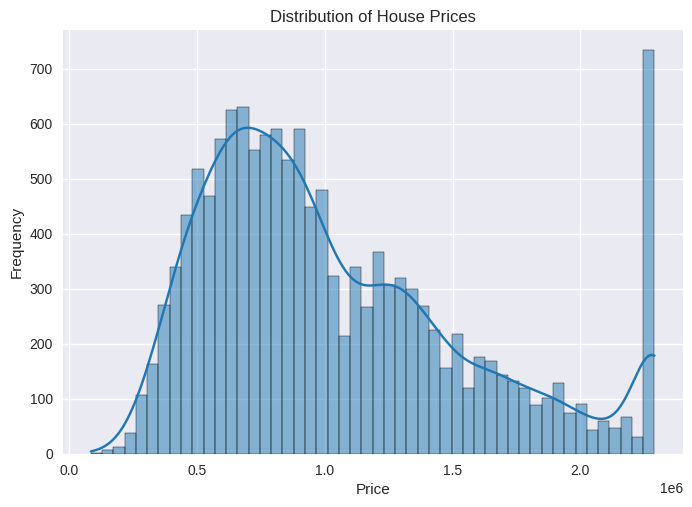

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['Price'], bins=50, kde=True)
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()


### Insight

The distribution of housing prices is right-skewed, indicating that most properties are concentrated in lower to mid price ranges while a smaller number of high-value properties extend the upper tail of the distribution.

This skewness suggests that extreme values may influence statistical modeling and supports the use of outlier treatment and robust modeling techniques in later stages of the analysis.

**Correlation Matrix**

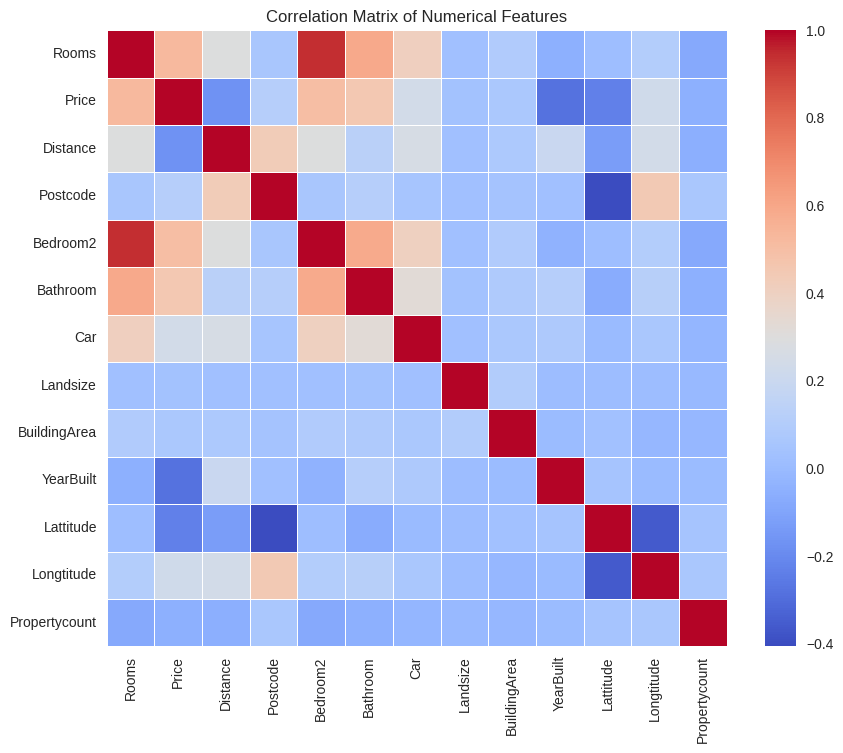

In [ ]:
plt.figure(figsize=(10, 8))

corr_matrix = df.corr(numeric_only=True)

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    annot=False,
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Features")
plt.show()


### Insight

The correlation matrix reveals relationships between numerical housing features. Variables such as Rooms, BuildingArea, and Landsize show positive associations with price, suggesting that larger properties generally command higher values.

Location-related variables such as Distance from the city center exhibit weaker or negative relationships with price, indicating that properties located farther from central Melbourne tend to sell for lower prices.

These relationships provide initial guidance for feature importance in predictive modeling.

**Key Relationship: Distance vs Price**

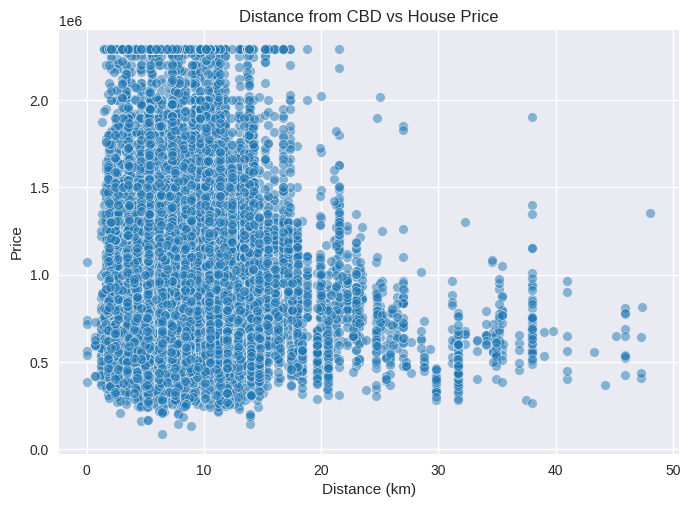

In [ ]:
sns.scatterplot(data=df, x='Distance', y='Price', alpha=0.5)
plt.title('Distance from CBD vs House Price')
plt.xlabel('Distance (km)')
plt.ylabel('Price')
plt.show()



### Insight

The scatter plot shows a general inverse relationship between distance from Melbourne's central business district and housing prices. Properties located closer to the city center tend to have higher prices, while prices generally decline as distance increases.

However, the wide spread of points indicates that other factors such as property size, number of rooms, and building characteristics also play significant roles in determining property value.

**Average Price by Property Type**

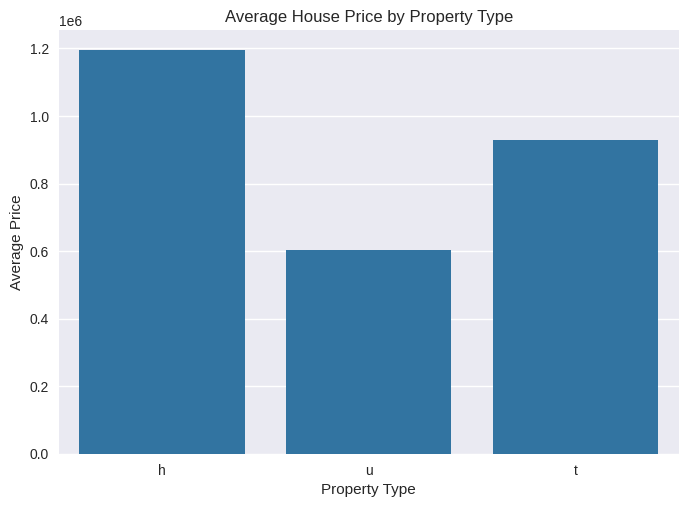

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Average price by property type
sns.barplot(
    data=df,
    x='Type',
    y='Price',
    estimator='mean',
    errorbar=None
)

plt.title('Average House Price by Property Type')
plt.xlabel('Property Type')
plt.ylabel('Average Price')
plt.show()


### Insight

Average housing prices vary noticeably by property type. Detached houses (type **h**) typically command the highest prices, while units or apartments (type **u**) tend to have lower average prices.

This pattern reflects typical real estate market dynamics where standalone houses generally offer larger land areas and more space compared to apartments or townhouses.

The exploratory analysis reveals several variables that appear to influence housing prices, including structural characteristics such as the number of rooms, building area, and land size, as well as location-based factors like distance from the city center.

These insights guide the feature selection and modeling approach used in the following sections.

## Model Preparation

After cleaning, encoding, and treating outliers, the dataset is prepared for predictive modeling.  
The target variable is Price, and the remaining features are used as predictors.

In [ ]:
from sklearn.model_selection import train_test_split

# Use encoded dataset for modeling
X = df_encoded.drop("Price", axis=1)
y = df_encoded["Price"]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (10864, 78)
X_test shape: (2716, 78)
y_train shape: (10864,)
y_test shape: (2716,)


In [ ]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\nData types:")
print(X_train.dtypes.value_counts())

X_train shape: (10864, 78)
X_test shape: (2716, 78)

Data types:
bool       66
float64    11
int64       1
Name: count, dtype: int64


## Baseline Model: Linear Regression

A Linear Regression model is used as a baseline to estimate housing prices and provide a point of comparison for more flexible models.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Train baseline model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predict on test set
y_pred_lr = lr_model.predict(X_test)

# Evaluate
lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_r2 = r2_score(y_test, y_pred_lr)

print("Linear Regression Performance")
print("MAE:", lr_mae)
print("RMSE:", lr_rmse)
print("R²:", lr_r2)

Linear Regression Performance
MAE: 269571.6359464363
RMSE: 409558.89660298015
R²: 0.5777123882352635


### Random Forest Hyperparameter Tuning

To improve model performance, a small hyperparameter search was conducted using RandomizedSearchCV. This process evaluates multiple combinations of model parameters to identify configurations that produce better predictive performance.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42, n_jobs=-1)

param_dist = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

rf_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=5,
    cv=2,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    random_state=42
)

rf_search.fit(X_train, y_train)

best_rf = rf_search.best_estimator_
print("Best Parameters:", rf_search.best_params_)
print("Best Cross-Validation Score:", rf_search.best_score_)

Best Parameters: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}


## Random Forest Regressor

A Random Forest Regressor is used to capture more complex, nonlinear relationships in the housing data. This model often performs better than linear regression on structured tabular datasets.

In [ ]:
# Train random forest model
rf_model = best_rf
rf_model.fit(X_train, y_train)

# Predict on test set
y_pred_rf = rf_model.predict(X_test)

# Evaluate
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2 = r2_score(y_test, y_pred_rf)

print("Random Forest Performance")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R²:", rf_r2)

Random Forest Performance
MAE: 163051.78498527245
RMSE: 269768.7043097796
R²: 0.8167859628183751


### Hyperparameter Tuning Insight

The tuned Random Forest model achieved an R² score of approximately 0.82, indicating that the model explains around 82% of the variance in housing prices within the dataset.

The MAE of roughly \$163k suggests that the model’s predictions typically deviate from actual sale prices by about \$163,000 on average. Considering the average property price is over \$1 million, this level of error is reasonable for a housing price prediction model.

These results demonstrate that the Random Forest model successfully captures key relationships between property characteristics and housing prices.

In [ ]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest Regressor"],
    "MAE": [lr_mae, rf_mae],
    "RMSE": [lr_rmse, rf_rmse],
    "R2": [lr_r2, rf_r2]
})

results

,Model,MAE,RMSE,R2
0,Linear Regression,269571.635946,409558.896603,0.577712
1,Random Forest Regressor,163051.784985,269768.704310,0.816786


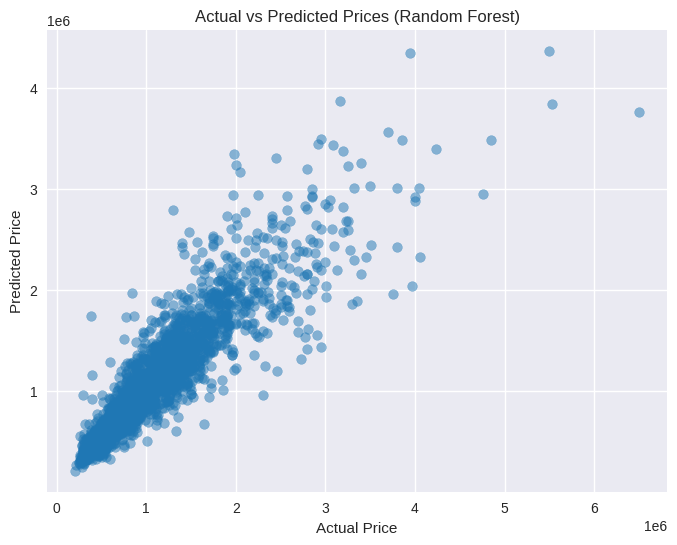

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.5)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices (Random Forest)")
plt.show()

## Model Evaluation

The Linear Regression model provides a useful baseline, while the Random Forest Regressor captures more complex relationships in the data. Model performance is evaluated using MAE, RMSE, and R².

Lower MAE and RMSE indicate better predictive accuracy, while a higher R² indicates that the model explains more variance in housing prices.

## Model Comparison

To summarize model performance, the baseline Linear Regression model is compared with the tuned Random Forest model using common regression evaluation metrics.

In [ ]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [lr_mae, rf_mae],
    "RMSE": [lr_rmse, rf_rmse],
    "R2": [lr_r2, rf_r2]
})

comparison

,Model,MAE,RMSE,R2
0,Linear Regression,269571.635946,409558.896603,0.577712
1,Random Forest,163051.784985,269768.704310,0.816786


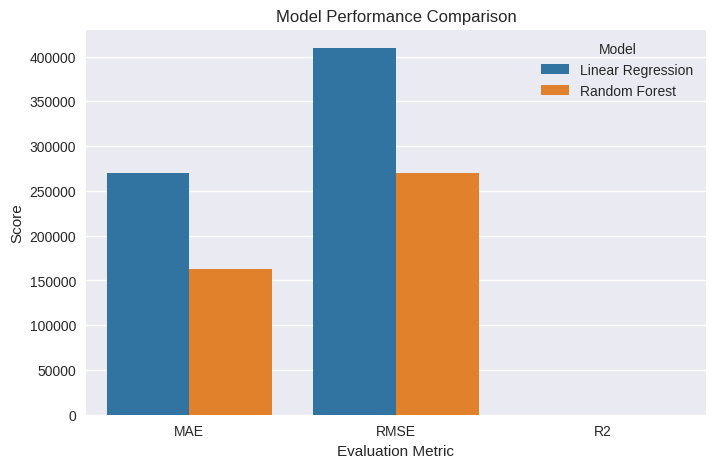

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

comparison_melt = comparison.melt(id_vars="Model", var_name="Metric", value_name="Value")

plt.figure(figsize=(8,5))
sns.barplot(data=comparison_melt, x="Metric", y="Value", hue="Model")

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Evaluation Metric")

plt.show()

### Model Comparison Insight

The Random Forest model significantly outperforms the baseline Linear Regression model across all evaluation metrics.

While Linear Regression provides a simple baseline for understanding the relationship between features and housing prices, Random Forest captures nonlinear interactions between variables such as property size, location, and amenities.

The higher R² score and lower error values indicate that the Random Forest model is better suited for predicting housing prices in this dataset.

## Feature Importance Analysis

To understand which variables most influence housing price predictions, feature importance scores were extracted from the trained Random Forest model. These scores represent the relative contribution of each feature to the model's decision-making process.

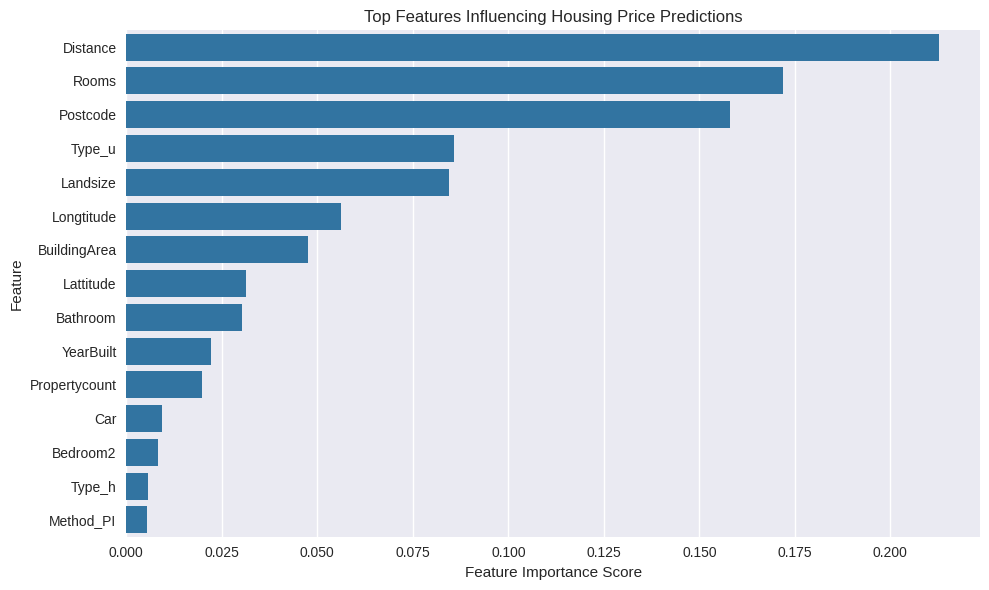

In [ ]:
# Extract feature importances from the trained Random Forest model
importances = rf_model.feature_importances_

# Create dataframe for visualization
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importances
})

# Sort features by importance
feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

# Plot top 15 features
plt.figure(figsize=(10,6))
sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top Features Influencing Housing Price Predictions")
plt.xlabel("Feature Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

The feature importance analysis highlights the variables that contribute most strongly to housing price predictions. Structural attributes such as the number of rooms, building area, and land size tend to have the strongest influence on predicted prices, while location-related factors such as distance from the city center also play a significant role.

These results align with common real estate valuation principles, where both property characteristics and location contribute to market value.

## Prediction Performance Visualization

To further evaluate model performance, predicted housing prices were compared with actual prices from the test dataset. A scatter plot helps visualize how closely predictions align with observed values.

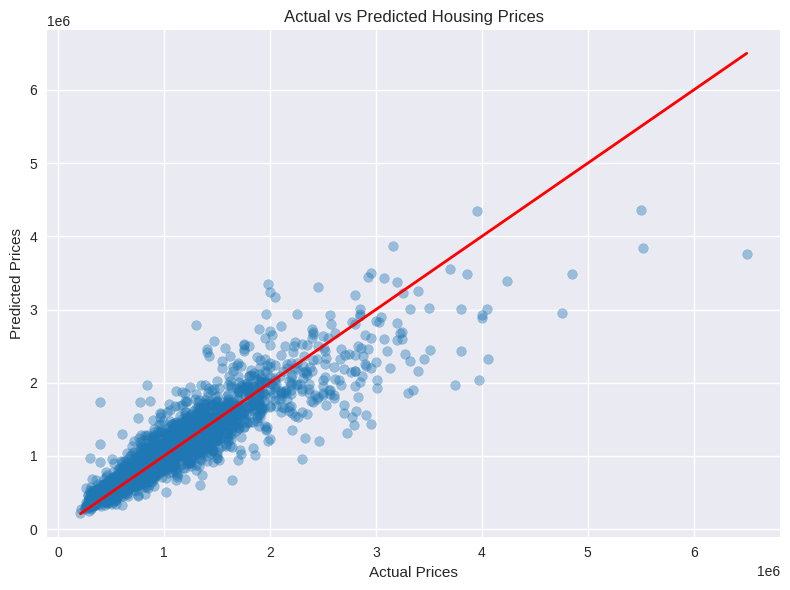

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred_rf, alpha=0.4)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.title("Actual vs Predicted Housing Prices")
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

plt.tight_layout()
plt.show()

The scatter plot compares predicted housing prices with actual values from the test dataset. Points closer to the diagonal reference line indicate more accurate predictions.

While some variation exists, the general clustering around the diagonal suggests that the Random Forest model captures key patterns in the data and provides reasonable price estimates.

## Conclusion

This project developed a machine learning workflow to predict housing prices using the Melbourne Housing Market dataset. The analysis followed a complete data science pipeline including data cleaning, feature transformation, exploratory data analysis, and predictive modeling.

Exploratory analysis revealed several key relationships within the dataset. Property characteristics such as the number of rooms, land size, and building area were positively associated with housing prices, while distance from the central business district showed a negative relationship with property value. These patterns are consistent with typical real estate market dynamics.

Two predictive models were implemented and evaluated. Linear Regression served as a baseline model, providing a simple and interpretable estimate of housing prices. A Random Forest Regressor was then trained to capture more complex nonlinear relationships between features. Hyperparameter tuning using RandomizedSearchCV further improved the model's performance.

The Random Forest model significantly outperformed the baseline Linear Regression model, achieving higher predictive accuracy and explaining a larger proportion of price variation in the dataset. Feature importance analysis indicated that property size, location-based attributes, and structural characteristics were among the most influential factors in predicting housing prices.

Overall, the results demonstrate that machine learning techniques can effectively model housing price patterns using structured real estate data. The Random Forest model provides a strong predictive baseline that could support further analysis or real estate valuation applications.

## Future Improvements

While the model performed well, several improvements could further enhance predictive accuracy and analytical depth:

- Incorporating additional geographic or neighborhood-level features such as proximity to schools, transportation, or commercial areas.
- Applying more advanced models such as Gradient Boosting, XGBoost, or LightGBM.
- Performing deeper hyperparameter tuning with larger search spaces and cross-validation.
- Applying feature scaling or dimensionality reduction techniques where appropriate.
- Evaluating model stability using additional validation strategies such as k-fold cross-validation.

Future work could also explore deploying the trained model in an application or dashboard that allows users to estimate housing prices based on property characteristics.